In [13]:
mkdir notebooks

A subdirectory or file notebooks already exists.


<Axes: title={'center': 'MOT Pass vs Fail Counts'}, xlabel='test_result'>

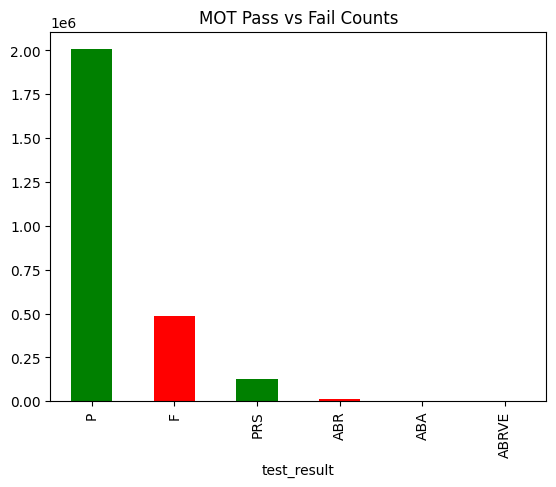

In [14]:
import pandas as pd

# 1. Load the data directly into the notebook memory
df = pd.read_parquet("../data/processed/mot_clean.parquet")

# 2. Let's see how many cars passed vs. failed!
df['test_result'].value_counts().plot(kind='bar', title='MOT Pass vs Fail Counts', color=['green', 'red'])

<Axes: title={'center': 'Top 10 Car Makes by Total MOT Failures'}, xlabel='make'>

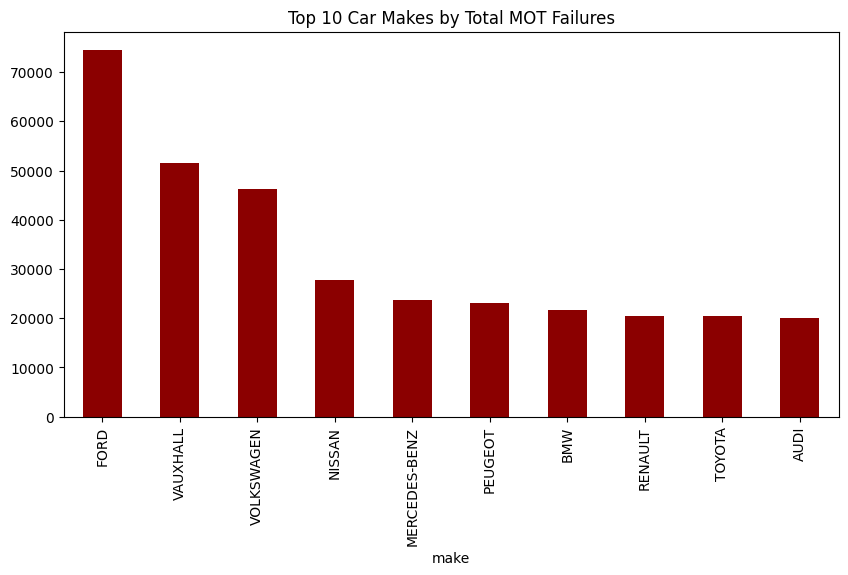

In [15]:
# 1. Filter the dataset to ONLY look at cars that Failed
failed_cars = df[df['test_result'] == 'F']

# 2. Count the top 10 Makes that failed, and plot it!
failed_cars['make'].value_counts().head(10).plot(
    kind='bar', 
    title='Top 10 Car Makes by Total MOT Failures', 
    color='darkred',
    figsize=(10, 5) # Makes the chart a bit wider so the names fit
)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load the failures directly from the raw CSV you downloaded
df_failures = pd.read_csv("../data/raw/test_item_202412.csv")

# 2. Load the dictionary (with the pipe separator!)
df_lookup = pd.read_csv("../data/raw/item_detail.csv", sep='|')

# 3. Merge them together
df_merged = pd.merge(df_failures, df_lookup, on='rfr_id', how='left')

# 4. Filter for actual Failures ('F')
actual_failures = df_merged[df_merged['rfr_type_code'] == 'F']

# 5. Count the top 10 most common English failure descriptions
top_failures = actual_failures['rfr_desc'].value_counts().head(10)

# 6. Plot the chart!
plt.figure(figsize=(12, 6))
top_failures.sort_values().plot(kind='barh', color='darkred')
plt.title('Top 10 Most Common MOT Failure Reasons (2024)', fontsize=14)
plt.xlabel('Number of Failures')
plt.ylabel('Failure Description')
plt.show()